In [1]:
import numpy as np
import seaborn as sns
import pandas as pd
import sys
from pathlib import Path
from matplotlib import pyplot as plt

from lmfit.model import load_modelresult


In [2]:
ROOT = Path.cwd()  

sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "py_modules"))

from pipeline_config import MAPS_DIR, FIGS_DIR 
import results_comp
import ci_results_compiler
import plot_fit_params
import list_maps_plots


# Loading files

In [3]:
filelist = "fits_ready/filelist_circles.txt"

with open(filelist, "r", encoding="utf-8") as f:
    names = [line.strip() for line in f if line.strip()]

In [4]:
bundles = {}

for name in names:
    bundles[name] = results_comp.load_line_bundle(
        name, name, MAPS_DIR, read_header=True
    )

In [5]:
dfs_obs  = {name: bundle["obs"]  for name, bundle in bundles.items()}
dfs_fit  = {name: bundle["fit"]  for name, bundle in bundles.items()}
meta_all = {name: bundle["meta"] for name, bundle in bundles.items()}

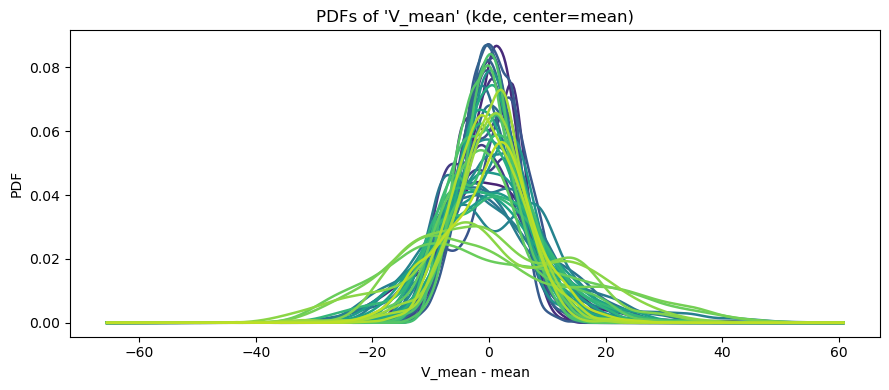

In [6]:
fig, ax, stats_df = list_maps_plots.plot_list_pdfs_circles(
    dfs_obs,
    col="V_mean",
    center="mean",
    method="kde",
    cmap="viridis",
    legend_mode="none",
    annotate=False,
    figsize=(9, 4),
    bw_scale=1.0
)

In [7]:
stats_df

,name,N,mean,std,var,xmin,xmax
0,LVM-30Dor-5007_C0,5421,-6.061761,10.010493,100.209977,-30.960257,51.452093
1,LVM-30Dor-5007_I1,5001,-5.497771,5.027239,25.273137,-19.970954,13.780475
2,LVM-30Dor-5007_I2,4830,-4.073921,4.950172,24.504200,-13.934308,23.586608
3,LVM-30Dor-5007_I3,5078,-5.184846,5.146020,26.481519,-14.844407,18.833023
4,LVM-30Dor-5007_I4,4555,0.639687,7.225409,52.206533,-18.050482,28.807228
5,LVM-30Dor-5007_I5,4314,-5.903402,7.732942,59.798388,-25.826418,33.074337
6,LVM-30Dor-5007_I6,4793,-4.633650,4.959422,24.595866,-15.175413,15.101413
7,LVM-30Dor-5007_I7,4607,-4.305296,5.531438,30.596805,-19.620686,20.698120
8,LVM-30Dor-5007_I8,4439,-3.988561,5.869595,34.452149,-23.046607,24.456776
9,LVM-30Dor-5007_M1,3535,0.634699,6.952076,48.331358,-21.018551,15.295485


In [8]:
#dfs_fit['LVM-30Dor-6563']

In [9]:
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.wcs import WCS
from astropy.visualization.wcsaxes.patches import SphericalCircle


c0 = SkyCoord.from_name("Tarantula")
fov_deg = 1.0  # Total field of view in degrees (width and height)
pix_scale = 1 / 3600
npix = int(fov_deg / pix_scale)

# Create WCS for TAN projection centered at 'center'
wcs = WCS(naxis=2)
wcs.wcs.ctype = ["RA---TAN", "DEC--TAN"]
wcs.wcs.crval = [c0.ra.deg, c0.dec.deg]
wcs.wcs.crpix = [npix, npix]  # center of your "image"
wcs.wcs.cdelt = [-pix_scale, pix_scale]  # field size / pixel count

In [17]:
name_file = "LVM-30Dor-5007"   # adjust if needed

circles_df = pd.read_csv("fits_ready/circle_catalog.csv")
circles_df["name"] = [f"{name_file}_{lab}" for lab in circles_df["label"]]

In [18]:

circles = []
for _, row in circles_df.iterrows():
    center = SkyCoord(
        ra=row["ra_deg"] * u.deg,
        dec=row["dec_deg"] * u.deg,
        frame="icrs"
    )

    circles.append({
        "name": row["name"],
        "label": row["label"],
        "ring": row["ring"],
        "angle_deg": row["angle_deg"],
        "center": center,
        "ra_deg": row["ra_deg"],
        "dec_deg": row["dec_deg"],
        "radius_arcsec": row["radius_arcsec"],
    })

In [19]:
circles

[{'name': 'LVM-30Dor-5007_C0',
  'label': 'C0',
  'ring': 'center',
  'angle_deg': nan,
  'center': <SkyCoord (ICRS): (ra, dec) in deg
      (84.675, -69.1)>,
  'ra_deg': 84.675,
  'dec_deg': -69.1,
  'radius_arcsec': 413.0},
 {'name': 'LVM-30Dor-5007_I1',
  'label': 'I1',
  'ring': 'inner',
  'angle_deg': 0.0,
  'center': <SkyCoord (ICRS): (ra, dec) in deg
      (84.675, -68.87055556)>,
  'ra_deg': 84.675,
  'dec_deg': -68.87055555555555,
  'radius_arcsec': 413.0},
 {'name': 'LVM-30Dor-5007_I2',
  'label': 'I2',
  'ring': 'inner',
  'angle_deg': 45.0,
  'center': <SkyCoord (ICRS): (ra, dec) in deg
      (85.1264378, -68.93716139)>,
  'ra_deg': 85.1264378029564,
  'dec_deg': -68.93716138661414,
  'radius_arcsec': 413.0},
 {'name': 'LVM-30Dor-5007_I3',
  'label': 'I3',
  'ring': 'inner',
  'angle_deg': 90.0,
  'center': <SkyCoord (ICRS): (ra, dec) in deg
      (85.31814997, -69.09879695)>,
  'ra_deg': 85.31814997110958,
  'dec_deg': -69.09879695321894,
  'radius_arcsec': 413.0},
 {'name

In [20]:
circles

[{'name': 'LVM-30Dor-5007_C0',
  'label': 'C0',
  'ring': 'center',
  'angle_deg': nan,
  'center': <SkyCoord (ICRS): (ra, dec) in deg
      (84.675, -69.1)>,
  'ra_deg': 84.675,
  'dec_deg': -69.1,
  'radius_arcsec': 413.0},
 {'name': 'LVM-30Dor-5007_I1',
  'label': 'I1',
  'ring': 'inner',
  'angle_deg': 0.0,
  'center': <SkyCoord (ICRS): (ra, dec) in deg
      (84.675, -68.87055556)>,
  'ra_deg': 84.675,
  'dec_deg': -68.87055555555555,
  'radius_arcsec': 413.0},
 {'name': 'LVM-30Dor-5007_I2',
  'label': 'I2',
  'ring': 'inner',
  'angle_deg': 45.0,
  'center': <SkyCoord (ICRS): (ra, dec) in deg
      (85.1264378, -68.93716139)>,
  'ra_deg': 85.1264378029564,
  'dec_deg': -68.93716138661414,
  'radius_arcsec': 413.0},
 {'name': 'LVM-30Dor-5007_I3',
  'label': 'I3',
  'ring': 'inner',
  'angle_deg': 90.0,
  'center': <SkyCoord (ICRS): (ra, dec) in deg
      (85.31814997, -69.09879695)>,
  'ra_deg': 85.31814997110958,
  'dec_deg': -69.09879695321894,
  'radius_arcsec': 413.0},
 {'name

Text(0.5, 1.0, 'Circle regions')

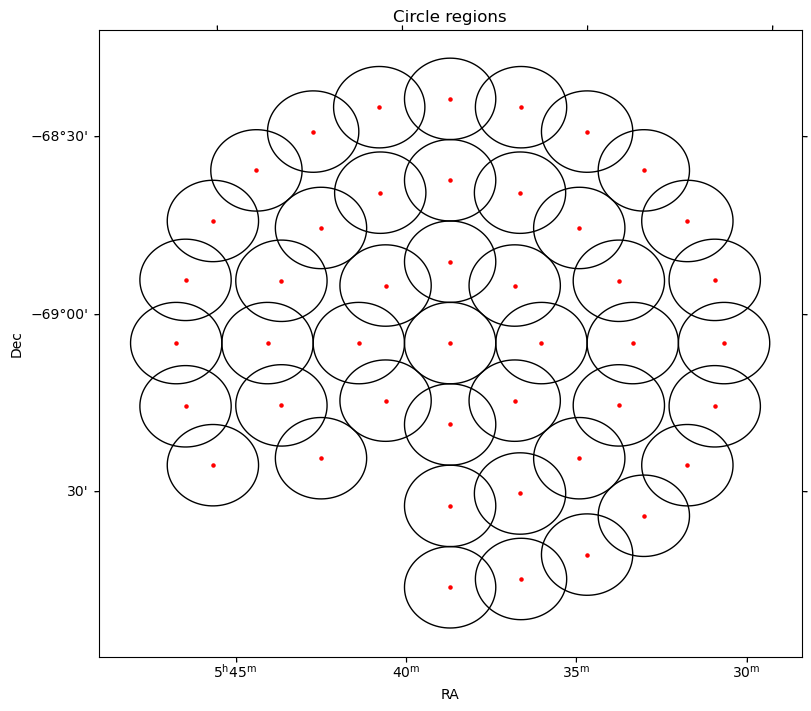

In [21]:
import matplotlib.pyplot as plt
import astropy.units as u
from astropy.visualization.wcsaxes.patches import SphericalCircle

fig = plt.figure(figsize=(8, 7), constrained_layout=True)
ax = fig.add_subplot(1, 1, 1, projection=wcs)

for item in circles:
    # draw center point
    ax.scatter(
        item["ra_deg"],
        item["dec_deg"],
        s=5,
        color="red",
        transform=ax.get_transform("world")
    )

    # draw circle
    circle = SphericalCircle(
        (item["center"].ra, item["center"].dec),
        item["radius_arcsec"] * u.arcsec,
        edgecolor="black",
        facecolor="none",
        linewidth=1.0,
        transform=ax.get_transform("world")
    )
    ax.add_patch(circle)

ax.set_xlabel("RA")
ax.set_ylabel("Dec")
ax.set_title("Circle regions")

Text(0.5, 1.0, 'Circle regions')

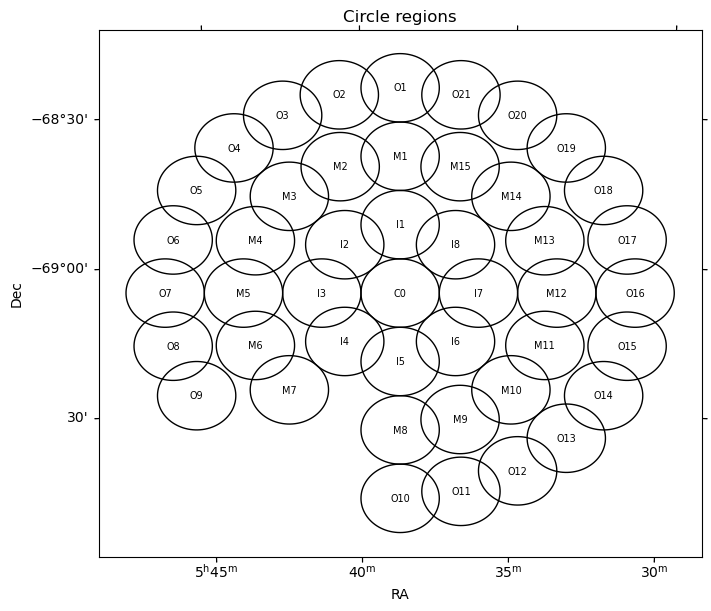

In [22]:
import matplotlib.pyplot as plt
import astropy.units as u
from astropy.visualization.wcsaxes.patches import SphericalCircle

fig = plt.figure(figsize=(7, 6), constrained_layout=True)
ax = fig.add_subplot(1, 1, 1, projection=wcs)

# anchor the WCS plot with the circle centers
ra_vals  = [item["ra_deg"] for item in circles]
dec_vals = [item["dec_deg"] for item in circles]

ax.scatter(
    ra_vals,
    dec_vals,
    s=1.0,
    color="white",
    alpha=0.01,
    transform=ax.get_transform("world")
)

for item in circles:
    circle = SphericalCircle(
        (item["center"].ra, item["center"].dec),
        item["radius_arcsec"] * u.arcsec,
        edgecolor="black",
        facecolor="none",
        linewidth=1,
        transform=ax.get_transform("world")
    )
    ax.add_patch(circle)

    ax.text(
        item["ra_deg"],
        item["dec_deg"],
        item["label"],
        transform=ax.get_transform("world"),
        ha="center",
        va="center",
        fontsize=7,
        color="black"
    )

ax.set_xlabel("RA")
ax.set_ylabel("Dec")
ax.set_title("Circle regions")

Text(0.5, 1.0, 'sig2 by circle')

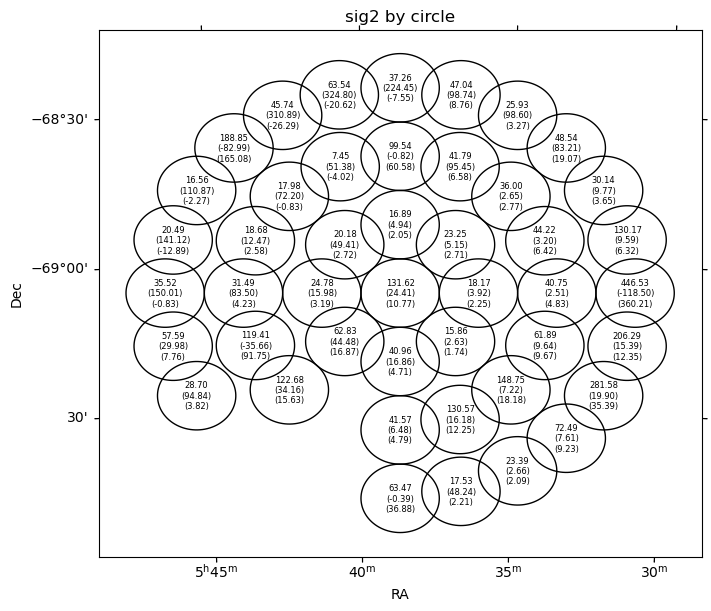

In [23]:
import matplotlib.pyplot as plt
import astropy.units as u
from astropy.visualization.wcsaxes.patches import SphericalCircle

fig = plt.figure(figsize=(7, 6), constrained_layout=True)
ax = fig.add_subplot(1, 1, 1, projection=wcs)

# anchor the WCS plot with the circle centers
ra_vals  = [item["ra_deg"] for item in circles]
dec_vals = [item["dec_deg"] for item in circles]

ax.scatter(
    ra_vals,
    dec_vals,
    s=1.0,
    color="white",
    alpha=0.01,
    transform=ax.get_transform("world")
)

for item in circles:
    name = item["name"]
    df_fit = dfs_fit[name]

    vals = df_fit["sig2"].tolist()[:3]
    txt = f"{vals[0]:.2f}\n({vals[1]:.2f})\n({vals[2]:.2f})"

    circle = SphericalCircle(
        (item["center"].ra, item["center"].dec),
        item["radius_arcsec"] * u.arcsec,
        edgecolor="black",
        facecolor="none",
        linewidth=1,
        transform=ax.get_transform("world")
    )
    ax.add_patch(circle)

    ax.text(
        item["ra_deg"],
        item["dec_deg"],
        txt,
        transform=ax.get_transform("world"),
        ha="center",
        va="center",
        fontsize=6,
        color="black"
    )

ax.set_xlabel("RA")
ax.set_ylabel("Dec")
ax.set_title("sig2 by circle")

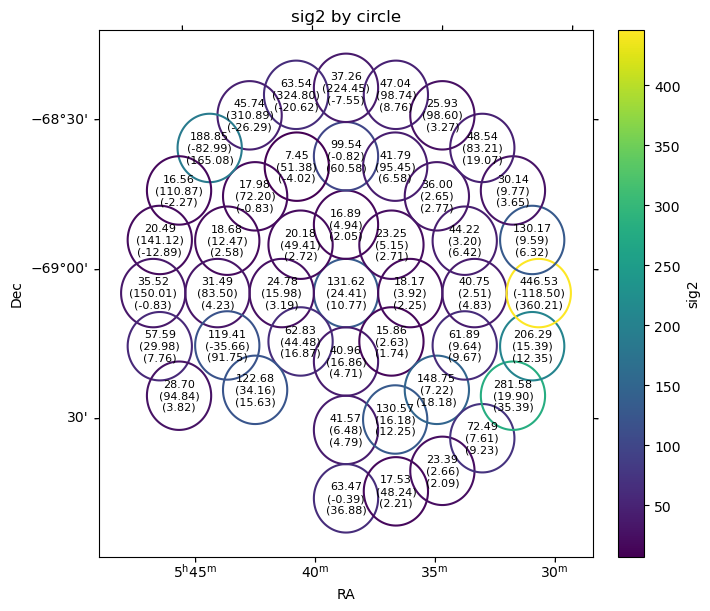

In [24]:
import matplotlib as mpl

fig = plt.figure(figsize=(7, 6), constrained_layout=True)
ax = fig.add_subplot(1, 1, 1, projection=wcs)

# anchor the WCS plot with the circle centers
ra_vals  = [item["ra_deg"] for item in circles]
dec_vals = [item["dec_deg"] for item in circles]

ax.scatter(
    ra_vals,
    dec_vals,
    s=1.0,
    color="white",
    alpha=0.01,
    transform=ax.get_transform("world")
)

# values used for the colormap: first row of sig2 in each circle
sig2_main = [dfs_fit[item["name"]]["sig2"].iloc[0] for item in circles]

norm = mpl.colors.Normalize(vmin=min(sig2_main), vmax=max(sig2_main))
cmap = plt.cm.viridis

for item in circles:
    name = item["name"]
    df_fit = dfs_fit[name]

    vals = df_fit["sig2"].tolist()[:3]
    txt = f"{vals[0]:.2f}\n({vals[1]:.2f})\n({vals[2]:.2f})"

    color = cmap(norm(vals[0]))

    circle = SphericalCircle(
        (item["center"].ra, item["center"].dec),
        item["radius_arcsec"] * u.arcsec,
        edgecolor=color,
        facecolor="none",
        linewidth=1.5,
        transform=ax.get_transform("world")
    )
    ax.add_patch(circle)

    ax.text(
        item["ra_deg"],
        item["dec_deg"],
        txt,
        transform=ax.get_transform("world"),
        ha="center",
        va="center",
        fontsize=8,   # bigger text
        color="black"
    )

ax.set_xlabel("RA")
ax.set_ylabel("Dec")
ax.set_title("sig2 by circle")

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("sig2")

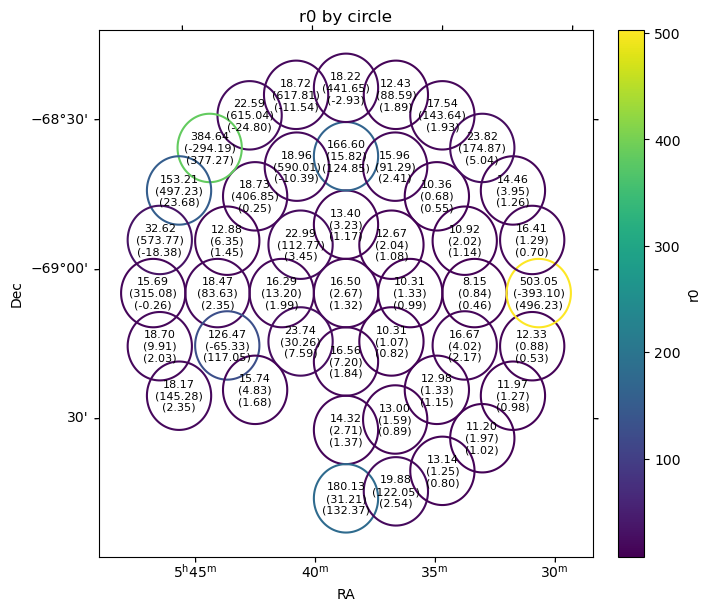

In [25]:
fig = plt.figure(figsize=(7, 6), constrained_layout=True)
ax = fig.add_subplot(1, 1, 1, projection=wcs)

# anchor the WCS plot with the circle centers
ra_vals  = [item["ra_deg"] for item in circles]
dec_vals = [item["dec_deg"] for item in circles]

ax.scatter(
    ra_vals,
    dec_vals,
    s=1.0,
    color="white",
    alpha=0.01,
    transform=ax.get_transform("world")
)

r0_main = [dfs_fit[item["name"]]["r0"].iloc[0] for item in circles]

norm = mpl.colors.Normalize(vmin=min(r0_main), vmax=max(r0_main))
cmap = plt.cm.viridis

for item in circles:
    name = item["name"]
    df_fit = dfs_fit[name]

    vals = df_fit["r0"].tolist()[:3]
    txt = f"{vals[0]:.2f}\n({vals[1]:.2f})\n({vals[2]:.2f})"

    color = cmap(norm(vals[0]))

    circle = SphericalCircle(
        (item["center"].ra, item["center"].dec),
        item["radius_arcsec"] * u.arcsec,
        edgecolor=color,
        facecolor="none",
        linewidth=1.5,
        transform=ax.get_transform("world")
    )
    ax.add_patch(circle)

    ax.text(
        item["ra_deg"],
        item["dec_deg"],
        txt,
        transform=ax.get_transform("world"),
        ha="center",
        va="center",
        fontsize=8,
        color="black"
    )

ax.set_xlabel("RA")
ax.set_ylabel("Dec")
ax.set_title("r0 by circle")

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("r0")

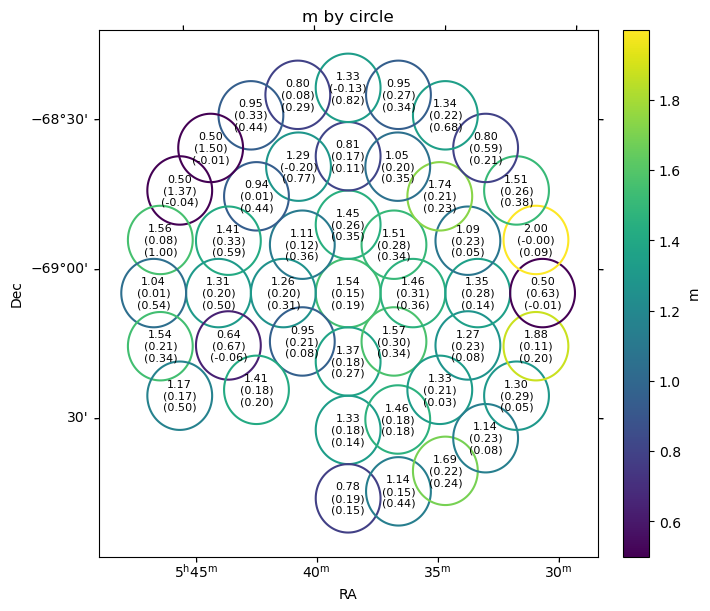

In [26]:
fig = plt.figure(figsize=(7, 6), constrained_layout=True)
ax = fig.add_subplot(1, 1, 1, projection=wcs)

# anchor the WCS plot with the circle centers
ra_vals  = [item["ra_deg"] for item in circles]
dec_vals = [item["dec_deg"] for item in circles]

ax.scatter(
    ra_vals,
    dec_vals,
    s=1.0,
    color="white",
    alpha=0.01,
    transform=ax.get_transform("world")
)

m_main = [dfs_fit[item["name"]]["m"].iloc[0] for item in circles]

norm = mpl.colors.Normalize(vmin=min(m_main), vmax=max(m_main))
cmap = plt.cm.viridis

for item in circles:
    name = item["name"]
    df_fit = dfs_fit[name]

    vals = df_fit["m"].tolist()[:3]
    txt = f"{vals[0]:.2f}\n({vals[1]:.2f})\n({vals[2]:.2f})"

    color = cmap(norm(vals[0]))

    circle = SphericalCircle(
        (item["center"].ra, item["center"].dec),
        item["radius_arcsec"] * u.arcsec,
        edgecolor=color,
        facecolor="none",
        linewidth=1.5,
        transform=ax.get_transform("world")
    )
    ax.add_patch(circle)

    ax.text(
        item["ra_deg"],
        item["dec_deg"],
        txt,
        transform=ax.get_transform("world"),
        ha="center",
        va="center",
        fontsize=8,
        color="black"
    )

ax.set_xlabel("RA")
ax.set_ylabel("Dec")
ax.set_title("m by circle")

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("m")